---
title: "Agricultural Flood Risk in Esperanza"
subtitle: "Calculating expected annual loss for crops using global flood data"
author: "Nissim Lebovits"
date: "2026-06-10"
execute:
  cache: true
  freeze: auto
---

## Introduction

This cookbook demonstrates how to assess agricultural flood risk using open data. We calculate Expected Annual Loss (EAL) for different crop types in Esperanza, a municipality in Santa Fe Province, Argentina. Unlike the Pergamino cookbook (which focuses on urban heat exposure), this analysis targets agricultural areas where flooding damages crops and threatens rural livelihoods.

You will learn how to:

- Load flood depth data at multiple return periods from JRC GloFAS
- Map crop distribution using INTA's National Crop Map
- Calculate hectares affected by flood depth thresholds
- Build an exposure table showing agricultural loss by crop type and return period
- Connect findings to policy recommendations

Santa Fe Province has experienced severe flooding from the Salado River, most notably in 2003 and 2016. Yet no provincial flood maps exist for this region. This analysis demonstrates how global datasets can fill critical data gaps for agricultural planning.

## Setup

In [1]:
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import rioxarray as rio
import requests
import warnings

from io import BytesIO
from pathlib import Path

warnings.filterwarnings("ignore", category=xr.SerializationWarning)

USE_CRS = "EPSG:5347"  # POSGAR 2007 / Argentina 5 (Santa Fe)
WGS84_CRS = "EPSG:4326"

DEFAULT_FIGSIZE = (10, 8)
plt.rcParams["figure.dpi"] = 100

## Study Area

Esperanza is located in Santa Fe Province, approximately 40 km west of the provincial capital. The municipality sits in the floodplain of the Salado River, making it vulnerable to periodic flooding. Agriculture dominates land use, with soy, corn, and wheat as primary crops.

In [2]:
ign_wfs_url = "https://wms.ign.gob.ar/geoserver/ign/ows"

params = {
    "service": "WFS",
    "version": "2.0.0",
    "request": "GetFeature",
    "typename": "ign:municipio",
    "outputFormat": "application/json",
    "CQL_FILTER": "nam='Esperanza'",
}

response = requests.get(ign_wfs_url, params=params)
esperanza = gpd.read_file(BytesIO(response.content))
esperanza = esperanza.to_crs(USE_CRS)

bbox_wgs84 = esperanza.to_crs(WGS84_CRS).total_bounds

print("Loaded Esperanza boundary")
print(f"Area: {esperanza.geometry.area.sum() / 1e6:.0f} km²")
print(f"Bounding box (WGS84): {bbox_wgs84}")

Loaded Esperanza boundary
Area: 287 km²
Bounding box (WGS84): [-61.03642827 -31.51442651 -60.76837483 -31.34987356]


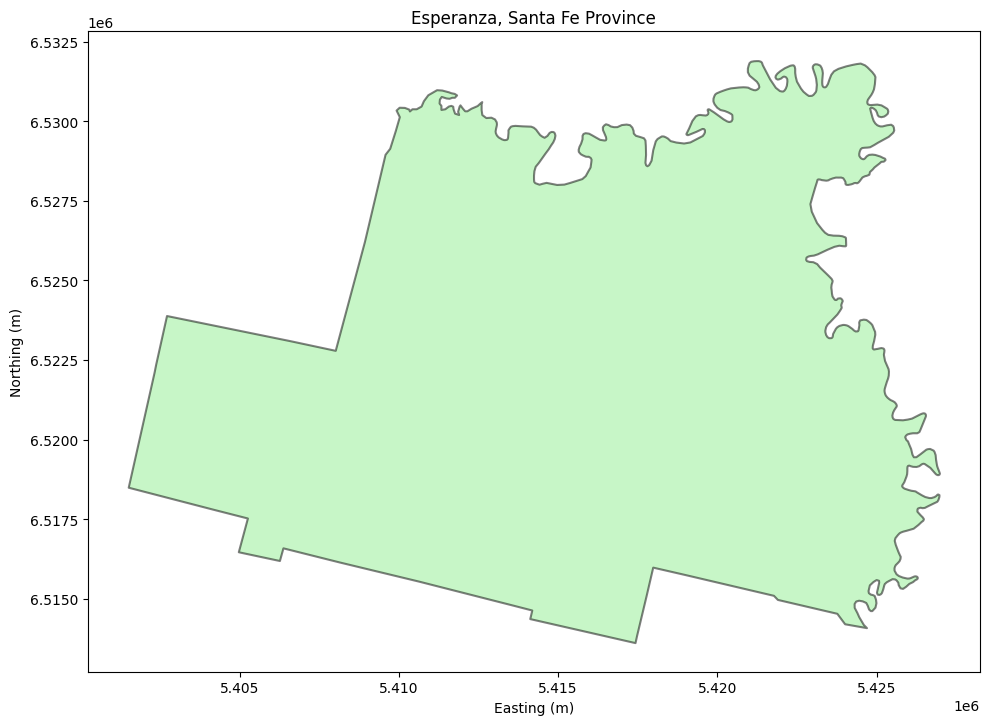

In [3]:
# | code-fold: true
# | code-summary: "Show visualization code"
fig, ax = plt.subplots(figsize=DEFAULT_FIGSIZE)

esperanza.plot(
    ax=ax, facecolor="lightgreen", edgecolor="black", linewidth=1.5, alpha=0.5
)

ax.set_title("Esperanza, Santa Fe Province")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.show()

## Hazard: Flood Depth by Return Period

We load flood depth data from the Joint Research Centre's Global Flood Awareness System (GloFAS). This dataset provides modeled flood depths at multiple return periods (RP): 20, 100, and 500 years. A 20-year return period flood has a 5% annual probability of occurrence; a 100-year flood has a 1% probability.

::: {.callout-tip}
## Why JRC GloFAS?

JRC GloFAS provides free, global coverage of flood hazard at ~90m resolution. For regions without local flood maps (like Santa Fe Province), global datasets are the only option. The data is derived from hydrological modeling rather than observed flooding, which means it captures potential flood extent rather than historical events. This is appropriate for risk assessment—we want to know what could happen, not just what has happened.
:::

In [4]:
return_periods = [10, 20, 50, 75, 100, 200, 500]
flood_depths = {}

for rp in return_periods:
    flood_depth_url = (
        f"https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/"
        f"CEMS-GLOFAS/flood_hazard/RP{rp}/ID75_S30_W70_RP{rp}_depth.tif"
    )

    flood_depth = rio.open_rasterio(
        flood_depth_url, masked=True, chunks={"x": 2048, "y": 2048}
    )

    aoi_bbox = esperanza.to_crs(flood_depth.rio.crs).total_bounds
    flood_depth_clipped = flood_depth.rio.clip_box(*aoi_bbox)

    flood_depth_reproj = flood_depth_clipped.rio.reproject(
        dst_crs=USE_CRS,
        resolution=30,
    ).rio.clip(esperanza.geometry)

    flood_depths[f"RP{rp}"] = flood_depth_reproj
    print(f"Loaded RP{rp}: max depth = {float(flood_depth_reproj.max()):.2f}m")

print(f"\nLoaded {len(flood_depths)} return periods")

Loaded RP10: max depth = 4.74m
Loaded RP20: max depth = 5.16m
Loaded RP50: max depth = 5.63m
Loaded RP75: max depth = 5.81m
Loaded RP100: max depth = 5.93m
Loaded RP200: max depth = 6.21m
Loaded RP500: max depth = 6.55m

Loaded 7 return periods


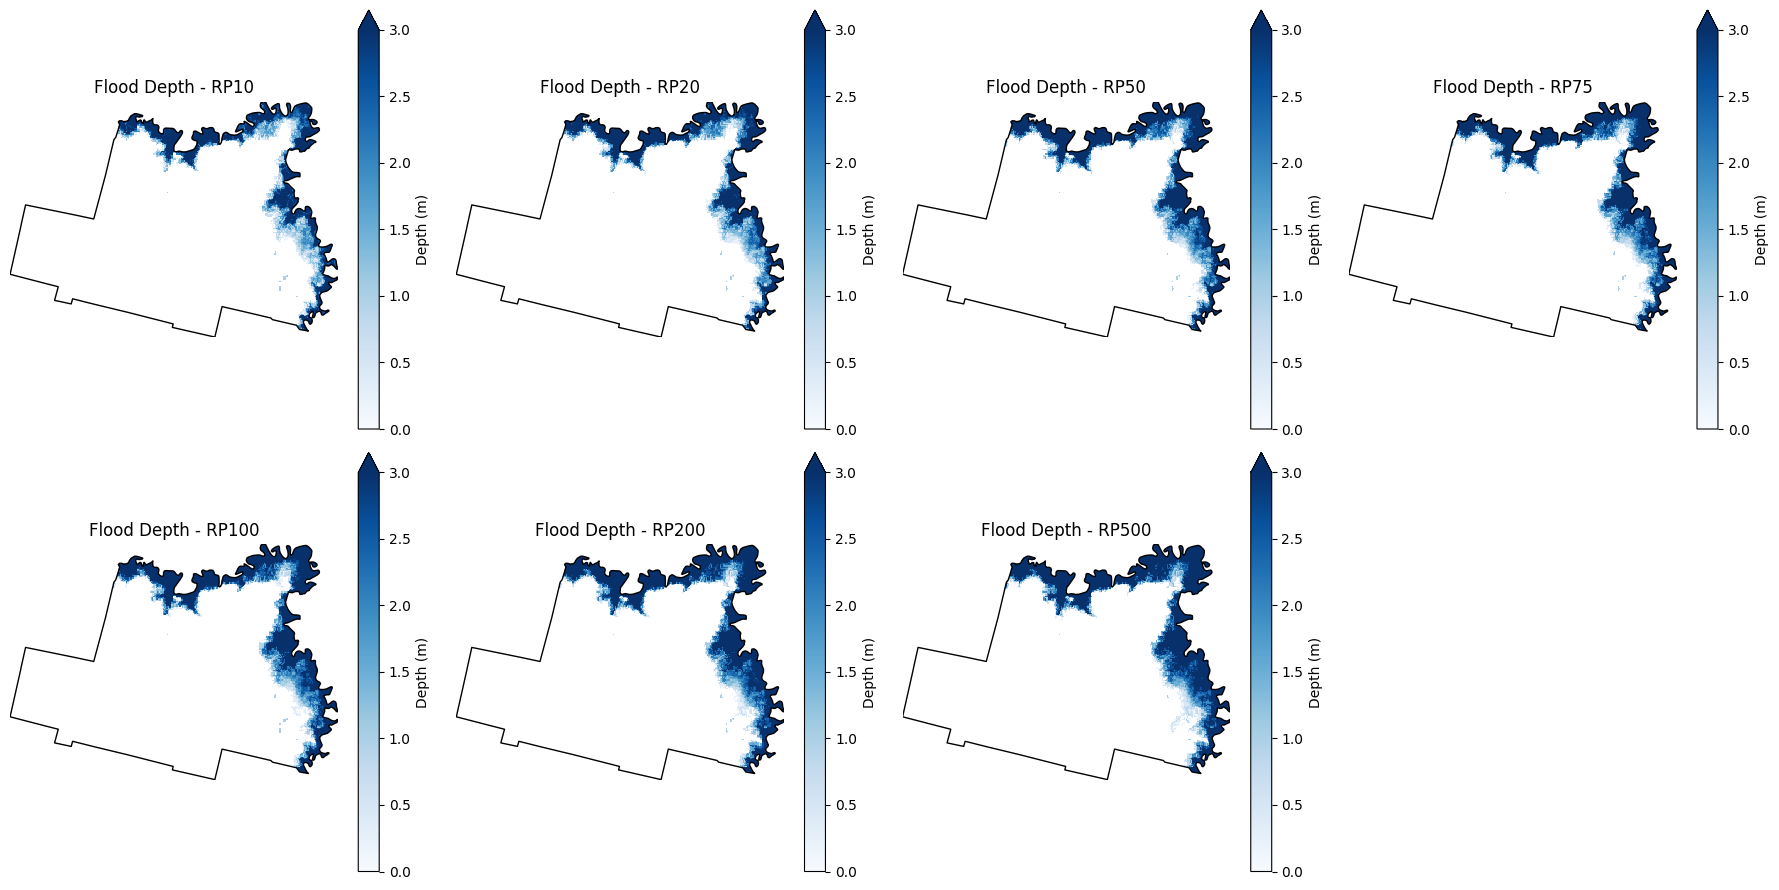

In [5]:
# | code-fold: true
# | code-summary: "Show visualization code"
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for idx, (rp_name, flood_data) in enumerate(flood_depths.items()):
    if idx < 7:
        flood_data.plot(
            ax=axes[idx],
            cmap="Blues",
            vmin=0,
            vmax=3,
            add_colorbar=True,
            cbar_kwargs={"label": "Depth (m)"},
        )
        esperanza.plot(ax=axes[idx], edgecolor="black", facecolor="none", linewidth=1)
        axes[idx].set_title(f"Flood Depth - {rp_name}")
        axes[idx].set_axis_off()

# Hide empty subplot
axes[7].set_visible(False)

plt.tight_layout()
plt.show()

### Validation Against Historic Floods

Esperanza experienced major flooding from the Salado River in 2003 and 2016. The municipality documented affected areas for both events, which include riparian zones and recreational areas along the river. We compare the modeled flood extent against these historic records to assess model plausibility.

::: {.callout-important}
## Model vs. Reality

GloFAS flood depths are modeled, not observed. Historic flood boundaries help validate whether the model captures realistic flood extents. However, the comparison has important limitations:

1. **Documented vs. actual extent**: The historic polygons may document areas where damage was assessed, not the full flood extent. Undeveloped agricultural land may have flooded without being mapped.

2. **Return period uncertainty**: The 2003 and 2016 events don't have assigned return periods. We cannot say "2003 was a 100-year flood"—only that the model's RP100 extent should plausibly encompass observed flooding.

3. **Different purposes**: Historic documentation often focuses on damage assessment for recovery funding, while hazard models aim to capture potential extent for planning.

Agreement in general location (both show flooding near the Salado) provides confidence. Exact boundary match is neither expected nor required.
:::

In [6]:
import zipfile
import urllib.request

historic_url = "https://arg-fulbright-data.s3.us-east-2.amazonaws.com/esperanza/datos_esperanza_3857.zip"
extract_dir = Path("datos_esperanza")
extract_dir.mkdir(exist_ok=True)

try:
    with urllib.request.urlopen(historic_url) as response:
        zip_data = response.read()
    with zipfile.ZipFile(BytesIO(zip_data), "r") as zip_ref:
        zip_ref.extractall(extract_dir)

    hist_2003 = gpd.read_file(extract_dir / "inundacion_historica_2003.geojson").to_crs(
        USE_CRS
    )
    hist_2016 = gpd.read_file(extract_dir / "inundacion_historica_2016.geojson").to_crs(
        USE_CRS
    )
    historic_available = True

    print("Loaded historic flood boundaries")
    print(f"2003 flood area: {hist_2003.geometry.area.sum() / 1e6:.1f} km²")
    print(f"2016 flood area: {hist_2016.geometry.area.sum() / 1e6:.1f} km²")
except Exception as e:
    historic_available = False
    print(f"Historic flood data not available: {e}")
    print("Proceeding without validation against historic events.")

Loaded historic flood boundaries
2003 flood area: 0.8 km²
2016 flood area: 0.3 km²


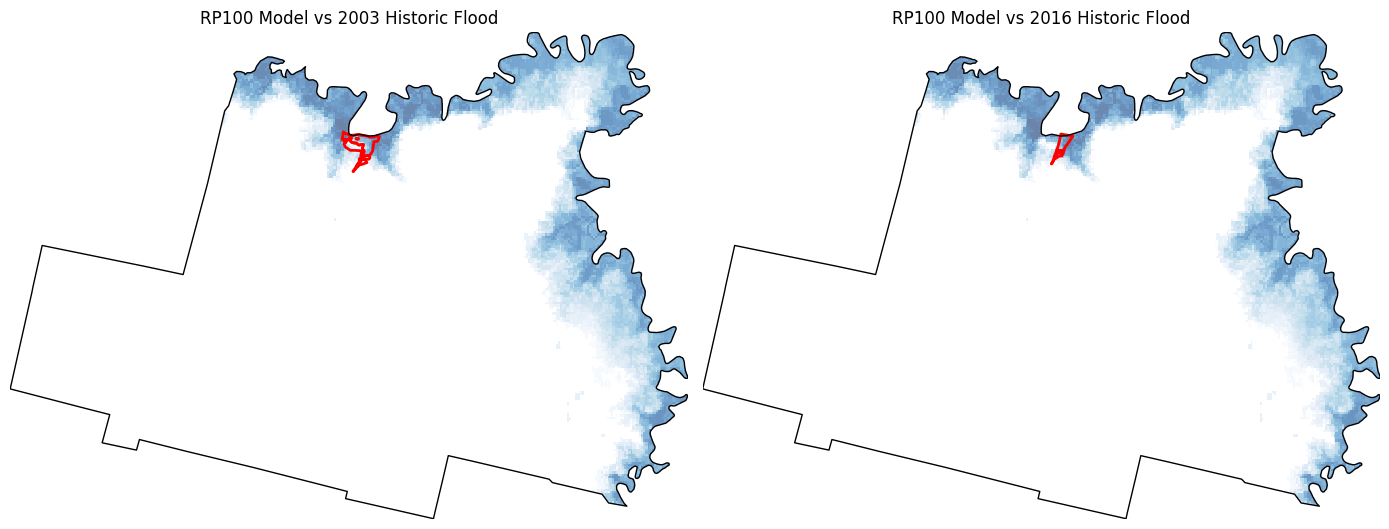

In [7]:
# | code-fold: true
# | code-summary: "Show visualization code"
if historic_available:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # 2003 event
    flood_depths["RP100"].plot(ax=axes[0], cmap="Blues", alpha=0.6, add_colorbar=False)
    hist_2003.plot(
        ax=axes[0], facecolor="none", edgecolor="red", linewidth=2, label="2003 flood"
    )
    esperanza.plot(ax=axes[0], edgecolor="black", facecolor="none", linewidth=1)
    axes[0].set_title("RP100 Model vs 2003 Historic Flood")
    axes[0].set_axis_off()

    # 2016 event
    flood_depths["RP100"].plot(ax=axes[1], cmap="Blues", alpha=0.6, add_colorbar=False)
    hist_2016.plot(
        ax=axes[1], facecolor="none", edgecolor="red", linewidth=2, label="2016 flood"
    )
    esperanza.plot(ax=axes[1], edgecolor="black", facecolor="none", linewidth=1)
    axes[1].set_title("RP100 Model vs 2016 Historic Flood")
    axes[1].set_axis_off()

    plt.tight_layout()
    plt.show()
else:
    print("Skipping validation visualization - historic data not available.")

## Agricultural Exposure: Crop Distribution

We load crop classification from INTA's National Crop Map (Mapa Nacional de Cultivos). This dataset maps agricultural land use across Argentina at 30m resolution, distinguishing between crop types including soy, corn, wheat, sunflower, and sorghum.

::: {.callout-tip}
## Why INTA MNC?

INTA (Instituto Nacional de Tecnología Agropecuaria) produces Argentina's official crop classification, combining Sentinel-2 and Landsat satellite imagery with field validation from agricultural extension stations. Unlike general land cover maps (MapBiomas, ESA WorldCover), INTA MNC distinguishes between specific crop types. This enables crop-specific damage assessment rather than treating all agriculture uniformly.
:::

In [8]:
mnc_url = "https://zenodo.org/records/13984185/files/MNC_verano-2024.tif"

mnc_cache = Path("MNC_verano-2024_esperanza.tif")

if mnc_cache.exists():
    print(f"Loading cached crop data from {mnc_cache}")
    crops = rio.open_rasterio(mnc_cache)
else:
    print("Downloading INTA MNC data (this may take a few minutes)...")
    crops_full = rio.open_rasterio(mnc_url, chunks={"x": 4096, "y": 4096})

    aoi_wgs84 = esperanza.to_crs(WGS84_CRS)
    crops_clipped = crops_full.rio.clip(aoi_wgs84.geometry, from_disk=True)
    crops = crops_clipped.rio.reproject(USE_CRS, resolution=30)

    crops.rio.to_raster(mnc_cache)
    print(f"Saved to {mnc_cache}")

print(f"Crop raster shape: {crops.shape}")

Loading cached crop data from MNC_verano-2024_esperanza.tif
Crop raster shape: (1, 616, 855)


In [9]:
CROP_CLASSES = {
    10: {"name": "Corn", "name_es": "Maíz", "color": "#0042ff"},
    11: {"name": "Soy", "name_es": "Soja", "color": "#339820"},
    12: {"name": "Sunflower", "name_es": "Girasol", "color": "#a41de2"},
    18: {"name": "Sorghum", "name_es": "Sorgo", "color": "#1e0f6b"},
    21: {"name": "Fallow", "name_es": "Barbecho", "color": "#646b63"},
    22: {"name": "Non-agricultural", "name_es": "No agrícola", "color": "#e6f0c2"},
}

AGRICULTURAL_CLASSES = [10, 11, 12, 18]

In [10]:
crops_values = crops.values.squeeze()
pixel_area_ha = (30 * 30) / 10000  # 30m pixels to hectares

crop_areas = []
for class_id, info in CROP_CLASSES.items():
    pixel_count = np.sum(crops_values == class_id)
    area_ha = pixel_count * pixel_area_ha
    crop_areas.append({"class_id": class_id, "crop": info["name"], "hectares": area_ha})

crop_df = pd.DataFrame(crop_areas)
crop_df = crop_df[crop_df["hectares"] > 0].sort_values("hectares", ascending=False)

print("CROP DISTRIBUTION IN ESPERANZA")
print("=" * 40)
for _, row in crop_df.iterrows():
    print(f"{row['crop']:<20} {row['hectares']:>10,.0f} ha")
print("-" * 40)
print(
    f"{'Total agricultural':<20} {crop_df[crop_df['class_id'].isin(AGRICULTURAL_CLASSES)]['hectares'].sum():>10,.0f} ha"
)

CROP DISTRIBUTION IN ESPERANZA
Non-agricultural         16,228 ha
Soy                       4,661 ha
Corn                      1,289 ha
Sorghum                      45 ha
----------------------------------------
Total agricultural        5,995 ha


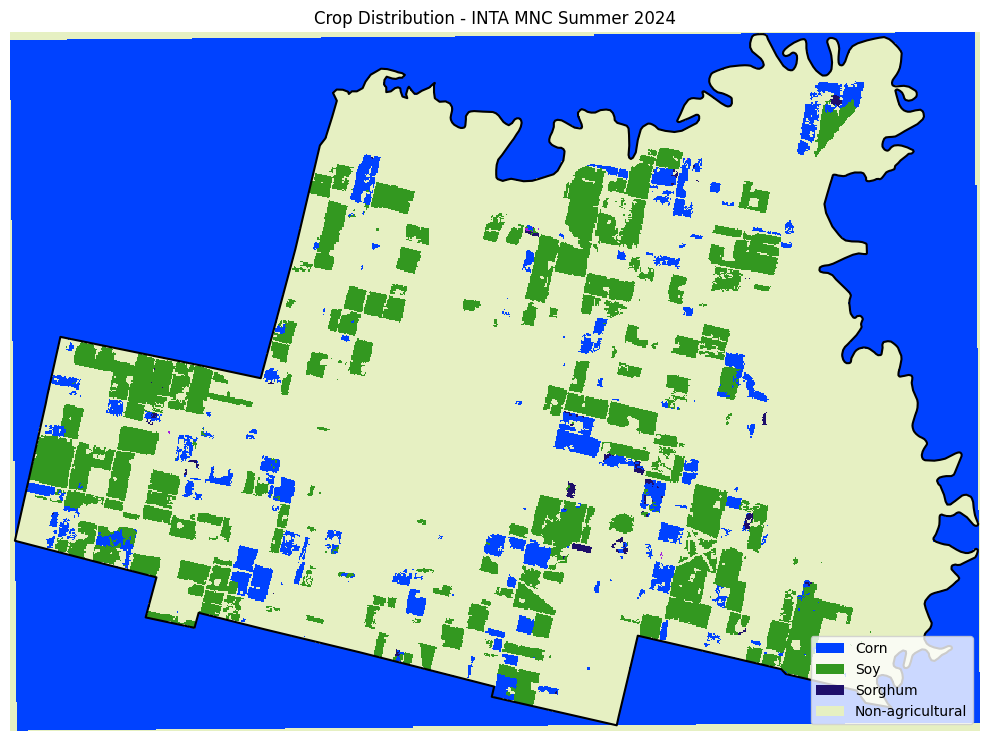

In [11]:
# | code-fold: true
# | code-summary: "Show visualization code"
import matplotlib.colors as mcolors

class_ids = sorted(CROP_CLASSES.keys())
colors = [CROP_CLASSES[c]["color"] for c in class_ids]
cmap = mcolors.ListedColormap(colors)
bounds = class_ids + [max(class_ids) + 1]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=DEFAULT_FIGSIZE)

crops.plot(ax=ax, cmap=cmap, norm=norm, add_colorbar=False)
esperanza.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.5)

legend_elements = [
    plt.Rectangle((0, 0), 1, 1, facecolor=info["color"], label=info["name"])
    for class_id, info in CROP_CLASSES.items()
    if class_id in crop_df["class_id"].values
]
ax.legend(handles=legend_elements, loc="lower right")

ax.set_title("Crop Distribution - INTA MNC Summer 2024")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Expected Annual Loss Calculation

Expected Annual Loss (EAL) integrates flood probability and exposure to estimate average annual agricultural losses. We use a binary damage threshold: crops in areas with flood depth greater than 0.3m are considered affected.

::: {.callout-note}
## Damage Threshold Simplification

We use a binary threshold (>0.3m = damaged) rather than depth-damage curves for several reasons:

1. **Crop-specific damage functions do not exist** for Argentine conditions. Published curves from temperate Europe or the US may not apply to soy/corn varieties grown here.
2. **Timing matters more than depth.** A 0.2m flood during harvest causes more damage than a 0.5m flood during dormancy. We lack the temporal resolution to model this.
3. **Binary is honest.** Reporting "1,200 hectares of soy affected by RP100 flooding" is actionable without false precision.

The 0.3m threshold represents approximately the height at which standing water causes significant crop stress. This is a pragmatic choice, not a calibrated model.
:::

In [12]:
crops_aligned = crops.rio.reproject_match(flood_depths["RP20"])
crops_aligned_values = crops_aligned.values.squeeze()

print(f"Aligned raster shape: {crops_aligned_values.shape}")
print(f"Flood raster shape: {flood_depths['RP20'].values.squeeze().shape}")

Aligned raster shape: (610, 849)
Flood raster shape: (610, 849)


In [13]:
DAMAGE_THRESHOLD = 0.3  # meters

exposure_results = []

for rp_name, flood_data in flood_depths.items():
    flood_values = flood_data.values.squeeze()
    affected_mask = flood_values > DAMAGE_THRESHOLD

    for class_id in AGRICULTURAL_CLASSES:
        crop_mask = crops_aligned_values == class_id
        affected_crop = crop_mask & affected_mask

        total_pixels = np.sum(crop_mask)
        affected_pixels = np.sum(affected_crop)

        total_ha = total_pixels * pixel_area_ha
        affected_ha = affected_pixels * pixel_area_ha

        exposure_results.append(
            {
                "return_period": rp_name,
                "crop": CROP_CLASSES[class_id]["name"],
                "total_ha": total_ha,
                "affected_ha": affected_ha,
                "pct_affected": (affected_ha / total_ha * 100) if total_ha > 0 else 0,
            }
        )

exposure_df = pd.DataFrame(exposure_results)

In [14]:
rp_cols = [f"RP{rp}" for rp in return_periods]

exposure_pivot = exposure_df.pivot_table(
    index="crop",
    columns="return_period",
    values="affected_ha",
    aggfunc="sum",
)[rp_cols]

exposure_pivot["Total (ha)"] = exposure_df.groupby("crop")["total_ha"].first().values

print("AGRICULTURAL EXPOSURE BY RETURN PERIOD")
print("=" * 80)
print(f"Damage threshold: >{DAMAGE_THRESHOLD}m flood depth")
print()
print(exposure_pivot.round(0).to_string())
print()
print("-" * 80)
totals = exposure_pivot.sum()
total_str = "TOTAL".ljust(12)
for rp in rp_cols:
    total_str += f" {totals[rp]:>7.0f}"
total_str += f" {totals['Total (ha)']:>12.0f}"
print(total_str)

AGRICULTURAL EXPOSURE BY RETURN PERIOD
Damage threshold: >0.3m flood depth

return_period  RP10  RP20  RP50  RP75  RP100  RP200  RP500  Total (ha)
crop                                                                  
Corn           55.0  68.0  86.0  95.0  100.0  108.0  114.0      1289.0
Sorghum         1.0   1.0   1.0   1.0    1.0    1.0    2.0        45.0
Soy            23.0  28.0  50.0  60.0   65.0   80.0   93.0      4661.0
Sunflower       0.0   0.0   0.0   0.0    0.0    0.0    0.0         0.0

--------------------------------------------------------------------------------
TOTAL             79      97     137     156     167     189     209         5995


### Computing Expected Annual Loss

EAL integrates across return periods using the exceedance probability curve. With seven return periods (10, 20, 50, 75, 100, 200, 500 years), we approximate the area under the curve using the trapezoidal rule:

$$EAL \approx \sum_{i} \frac{(L_{i} + L_{i+1})}{2} \times (P_{i} - P_{i+1})$$

Where $L_i$ is the loss at return period $i$ and $P_i = 1/RP_i$ is the annual exceedance probability. The shaded area under the exceedance probability curve represents the expected annual loss—the average hectares affected per year when accounting for all flood frequencies.

In [15]:
def calculate_eal(losses_by_rp, return_periods):
    """Calculate Expected Annual Loss using trapezoidal integration."""
    probs = [1 / rp for rp in return_periods]
    losses = [losses_by_rp.get(f"RP{rp}", 0) for rp in return_periods]

    eal = 0
    for i in range(len(return_periods) - 1):
        avg_loss = (losses[i] + losses[i + 1]) / 2
        prob_diff = probs[i] - probs[i + 1]
        eal += avg_loss * prob_diff

    # Add tail beyond lowest probability
    eal += losses[-1] * probs[-1]

    return eal


eal_by_crop = []
for crop in exposure_pivot.index:
    losses = {f"RP{rp}": exposure_pivot.loc[crop, f"RP{rp}"] for rp in return_periods}
    eal = calculate_eal(losses, return_periods)
    eal_by_crop.append(
        {
            "crop": crop,
            "eal_ha": eal,
            "total_ha": exposure_pivot.loc[crop, "Total (ha)"],
        }
    )

eal_df = pd.DataFrame(eal_by_crop)
eal_df["eal_pct"] = eal_df["eal_ha"] / eal_df["total_ha"] * 100

print("EXPECTED ANNUAL LOSS BY CROP")
print("=" * 50)
print(f"{'Crop':<15} {'EAL (ha)':<12} {'Total (ha)':<12} {'EAL %':<10}")
print("-" * 50)
for _, row in eal_df.iterrows():
    pct_str = (
        f"{row['eal_pct']:.2f}%"
        if pd.notna(row["eal_pct"]) and row["total_ha"] > 0
        else "N/A"
    )
    print(
        f"{row['crop']:<15} {row['eal_ha']:>10.1f} {row['total_ha']:>12.0f} {pct_str:>9}"
    )
print("-" * 50)
total_eal = eal_df["eal_ha"].sum()
total_area = eal_df["total_ha"].sum()
print(
    f"{'TOTAL':<15} {total_eal:>10.1f} {total_area:>12.0f} {total_eal / total_area * 100:>8.2f}%"
)

EXPECTED ANNUAL LOSS BY CROP
Crop            EAL (ha)     Total (ha)   EAL %     
--------------------------------------------------
Corn                   7.4         1289     0.57%
Sorghum                0.1           45     0.20%
Soy                    3.8         4661     0.08%
Sunflower              0.0            0       N/A
--------------------------------------------------
TOTAL                 11.3         5995     0.19%


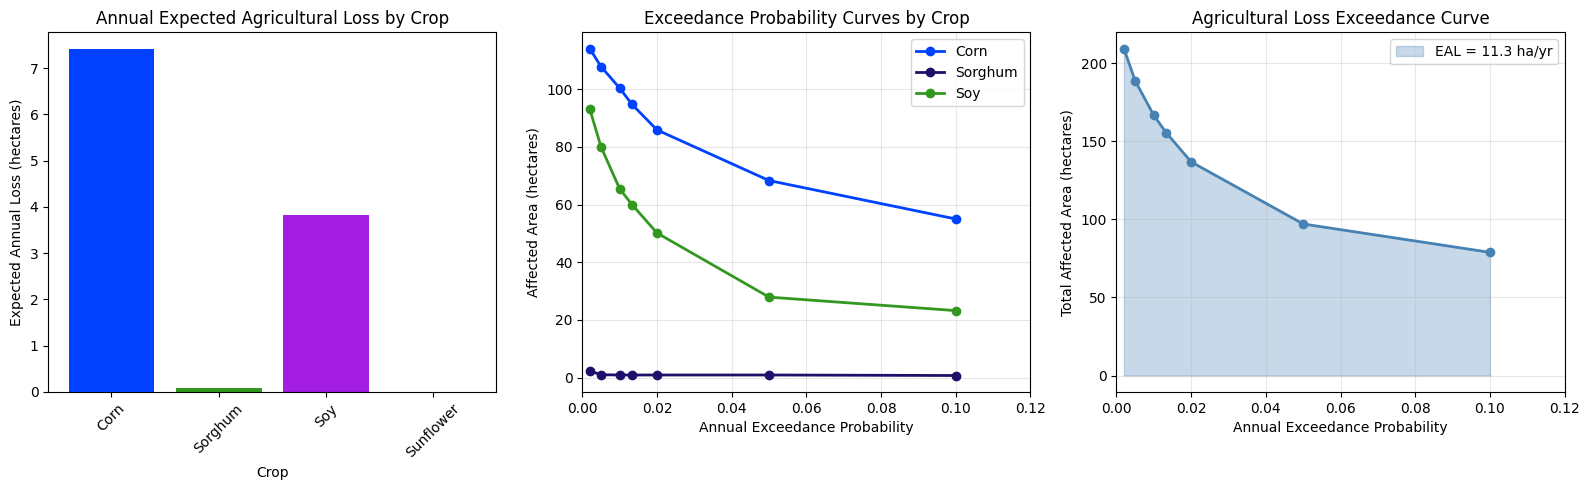

In [16]:
# | code-fold: true
# | code-summary: "Show visualization code"
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: EAL by crop
colors = [
    CROP_CLASSES[c]["color"]
    for c in AGRICULTURAL_CLASSES
    if CROP_CLASSES[c]["name"] in eal_df["crop"].values
]
axes[0].bar(eal_df["crop"], eal_df["eal_ha"], color=colors)
axes[0].set_xlabel("Crop")
axes[0].set_ylabel("Expected Annual Loss (hectares)")
axes[0].set_title("Annual Expected Agricultural Loss by Crop")
axes[0].tick_params(axis="x", rotation=45)

# Plot 2: Exceedance probability curves (EP curves)
probs = [1 / rp for rp in return_periods]
for crop in eal_df[eal_df["total_ha"] > 0]["crop"]:
    losses = [exposure_pivot.loc[crop, f"RP{rp}"] for rp in return_periods]
    class_id = [k for k, v in CROP_CLASSES.items() if v["name"] == crop][0]
    axes[1].plot(
        probs,
        losses,
        marker="o",
        label=crop,
        color=CROP_CLASSES[class_id]["color"],
        linewidth=2,
    )

axes[1].set_xlabel("Annual Exceedance Probability")
axes[1].set_ylabel("Affected Area (hectares)")
axes[1].set_title("Exceedance Probability Curves by Crop")
axes[1].legend()
axes[1].set_xlim(0, 0.12)
axes[1].grid(alpha=0.3)

# Plot 3: Total loss curve with shaded EAL area
total_losses = [exposure_pivot[f"RP{rp}"].sum() for rp in return_periods]
axes[2].fill_between(
    probs,
    total_losses,
    alpha=0.3,
    color="steelblue",
    label=f"EAL = {total_eal:.1f} ha/yr",
)
axes[2].plot(probs, total_losses, marker="o", color="steelblue", linewidth=2)
axes[2].set_xlabel("Annual Exceedance Probability")
axes[2].set_ylabel("Total Affected Area (hectares)")
axes[2].set_title("Agricultural Loss Exceedance Curve")
axes[2].legend()
axes[2].set_xlim(0, 0.12)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Going Further: Field-Level Analysis with FoTW

The raster analysis above treats agriculture as a continuous surface, counting only pixels that exceed the damage threshold. For operational use, we can attribute exposure to individual field parcels using the Fields of the World (FoTW) dataset from Source Cooperative.

::: {.callout-note}
## Pixel-Level vs Field-Level: Different Questions, Different Answers

These two approaches answer different questions:

**Pixel-level (raster)**: "How many hectares of crops are directly flooded?" This is the more accurate measure of physical exposure—only counting area actually underwater.

**Field-level**: "How many fields are affected, and what is their total area?" A field with *any* flooding is operationally affected—the farmer cannot harvest flooded portions, and equipment access may be compromised for the entire parcel.

Field-level exposure will always exceed pixel-level because partial flooding counts the whole field. The ratio between them (typically 5-15×) indicates how fragmented vs. concentrated flood exposure is. A high ratio means many fields have small flood footprints; a low ratio means flooding concentrates in fewer, more severely affected fields.

Both metrics matter for different decisions:
- **Insurance payouts**: Pixel-level is fairer for indemnity calculation
- **Farmer notification**: Field-level identifies who needs to prepare
- **Infrastructure planning**: Pixel-level shows where drainage investments have most impact
:::

::: {.callout-warning}
## Temporal Mismatch

FoTW field boundaries and INTA crop classification come from different time periods. A field boundary from 2022 may contain different crops in 2024 due to rotation. We assign crop type via zonal majority (most common crop pixels within each field), acknowledging this limitation.
:::

In [17]:
import duckdb

fotw_cache = Path("fotw_esperanza.parquet")

if fotw_cache.exists():
    print(f"Loading cached FoTW data from {fotw_cache}")
    fields = gpd.read_parquet(fotw_cache)
    fields_available = len(fields) > 0
else:
    con = duckdb.connect()
    for cmd in [
        "INSTALL spatial",
        "LOAD spatial",
        "INSTALL httpfs",
        "LOAD httpfs",
        "SET s3_region='us-west-2'",
        "SET s3_endpoint='data.source.coop'",
        "SET s3_use_ssl=true",
        "SET s3_url_style='path'",
    ]:
        con.execute(cmd)

    bounds = esperanza.to_crs(WGS84_CRS).total_bounds

    query = f"""
    SELECT ST_AsWKB(geometry) as geometry
    FROM 's3://ftw/global-data/predictions/vectors/alpha/results-fiboa/*.parquet'
    WHERE bbox.xmax >= {bounds[0]}
      AND bbox.xmin <= {bounds[2]}
      AND bbox.ymax >= {bounds[1]}
      AND bbox.ymin <= {bounds[3]}
    """

    try:
        df = con.execute(query).fetchdf()
        df["geometry"] = gpd.GeoSeries.from_wkb(df["geometry"].apply(bytes))
        fields = gpd.GeoDataFrame(df, geometry="geometry", crs=WGS84_CRS)
        fields = fields.to_crs(USE_CRS)
        fields = gpd.clip(fields, esperanza)
        fields_available = len(fields) > 0

        if fields_available:
            fields.to_parquet(fotw_cache)
            print(f"Saved FoTW cache to {fotw_cache}")

        print(f"Loaded {len(fields)} field parcels from FoTW")
    except Exception as e:
        fields_available = False
        print(f"FoTW data not available: {e}")
        print("Skipping field-level analysis.")
    finally:
        con.close()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Saved FoTW cache to fotw_esperanza.parquet
Loaded 1615 field parcels from FoTW


In [18]:
if fields_available:
    from rasterstats import zonal_stats

    # Assign crop type to each field via zonal majority
    crop_stats = zonal_stats(
        fields.geometry,
        crops_aligned_values,
        affine=crops_aligned.rio.transform(),
        stats=["majority"],
        nodata=0,
    )
    fields["crop_class"] = [s["majority"] for s in crop_stats]
    fields["crop_name"] = fields["crop_class"].map(
        {k: v["name"] for k, v in CROP_CLASSES.items()}
    )
    fields["area_ha"] = fields.geometry.area / 10000

    # Calculate flood stats for ALL return periods
    field_flood_results = []

    for rp in return_periods:
        rp_name = f"RP{rp}"
        flood_values = flood_depths[rp_name].values.squeeze()

        flood_stats = zonal_stats(
            fields.geometry,
            flood_values,
            affine=flood_depths[rp_name].rio.transform(),
            stats=["max", "mean"],
            nodata=np.nan,
        )
        fields[f"max_depth_{rp_name}"] = [s["max"] or 0 for s in flood_stats]
        fields[f"mean_depth_{rp_name}"] = [s["mean"] or 0 for s in flood_stats]
        fields[f"affected_{rp_name}"] = (
            fields[f"max_depth_{rp_name}"] > DAMAGE_THRESHOLD
        )

    # Filter to agricultural fields
    ag_fields = fields[fields["crop_class"].isin(AGRICULTURAL_CLASSES)].copy()

    # Build comparison table: pixel-level vs field-level
    print("PIXEL-LEVEL VS FIELD-LEVEL EXPOSURE COMPARISON")
    print("=" * 80)
    print(
        f"{'Return Period':<15} {'Pixel (ha)':<12} {'Field (ha)':<12} {'Field/Pixel':<12} {'Fields Affected':<15}"
    )
    print("-" * 80)

    for rp in return_periods:
        rp_name = f"RP{rp}"
        pixel_ha = exposure_pivot[rp_name].sum()
        field_ha = ag_fields[ag_fields[f"affected_{rp_name}"]]["area_ha"].sum()
        ratio = field_ha / pixel_ha if pixel_ha > 0 else 0
        n_fields = ag_fields[f"affected_{rp_name}"].sum()
        print(
            f"{rp_name:<15} {pixel_ha:>10.0f} {field_ha:>12.0f} {ratio:>10.1f}x {n_fields:>14}"
        )

    print()
    print("FIELD-LEVEL FLOOD DEPTH STATISTICS")
    print("=" * 80)
    print(
        f"{'Return Period':<15} {'Max Depth (m)':<15} {'Mean Max (m)':<15} {'Fields >1m':<12}"
    )
    print("-" * 80)

    for rp in return_periods:
        rp_name = f"RP{rp}"
        max_depth = ag_fields[f"max_depth_{rp_name}"].max()
        mean_max = ag_fields[ag_fields[f"affected_{rp_name}"]][
            f"max_depth_{rp_name}"
        ].mean()
        deep_fields = (ag_fields[f"max_depth_{rp_name}"] > 1.0).sum()
        mean_str = f"{mean_max:.2f}" if not np.isnan(mean_max) else "N/A"
        print(f"{rp_name:<15} {max_depth:>13.2f} {mean_str:>15} {deep_fields:>11}")

    print()
    print(f"Total agricultural fields: {len(ag_fields)}")
    print(f"Total field area: {ag_fields['area_ha'].sum():,.0f} ha")
else:
    print("Field-level analysis skipped.")

PIXEL-LEVEL VS FIELD-LEVEL EXPOSURE COMPARISON
Return Period   Pixel (ha)   Field (ha)   Field/Pixel  Fields Affected
--------------------------------------------------------------------------------
RP10                    79         1098       13.9x             18
RP20                    97         1278       13.2x             20
RP50                   137         1319        9.6x             23
RP75                   156         1319        8.5x             23
RP100                  167         1417        8.5x             26
RP200                  189         1424        7.5x             27
RP500                  209         1450        6.9x             28

FIELD-LEVEL FLOOD DEPTH STATISTICS
Return Period   Max Depth (m)   Mean Max (m)    Fields >1m  
--------------------------------------------------------------------------------
RP10                     2.52            1.41          11
RP20                     2.91            1.61          13
RP50                     3.35         

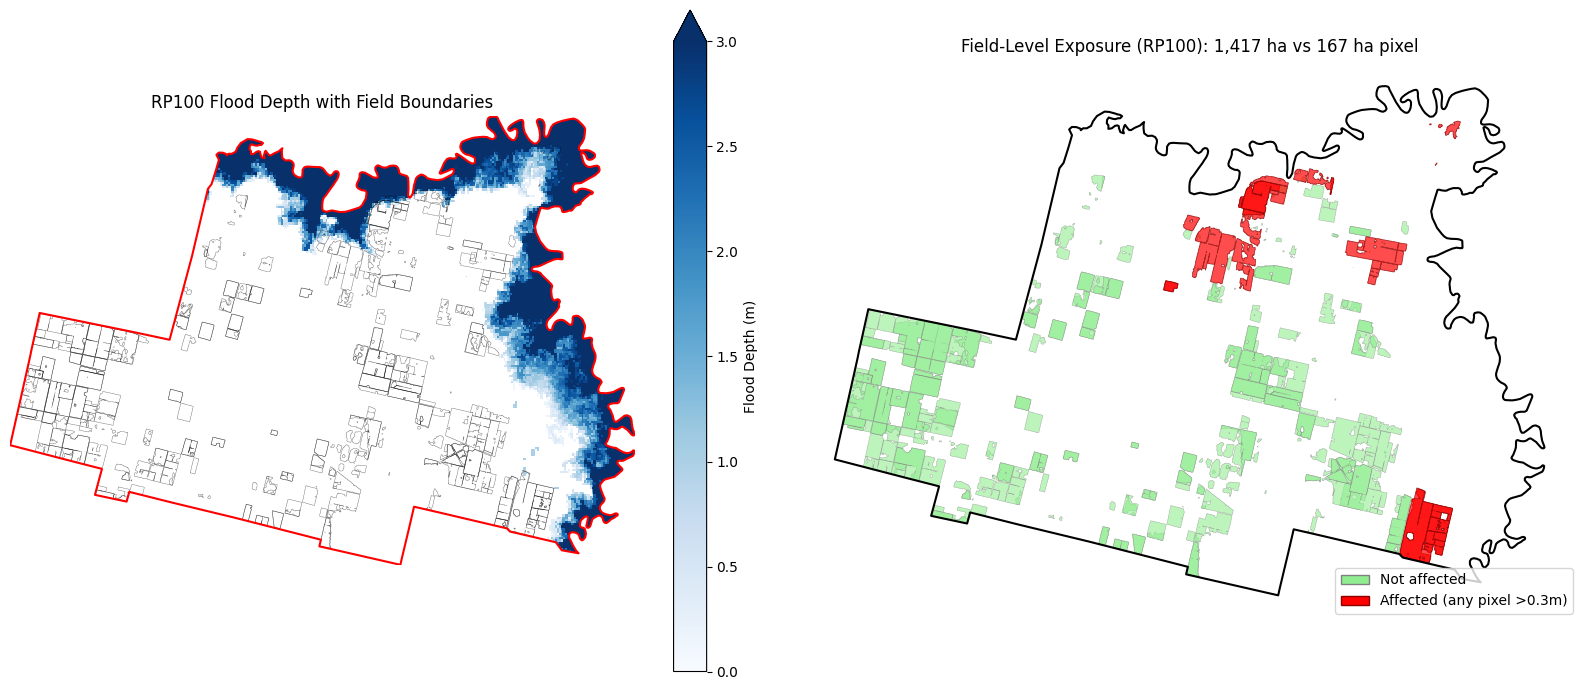

In [19]:
# | code-fold: true
# | code-summary: "Show visualization code"
if fields_available and len(ag_fields) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Left: Pixel-level flood depth with field boundaries
    flood_depths["RP100"].plot(
        ax=axes[0],
        cmap="Blues",
        vmin=0,
        vmax=3,
        add_colorbar=True,
        cbar_kwargs={"label": "Flood Depth (m)"},
    )
    ag_fields.plot(
        ax=axes[0], facecolor="none", edgecolor="black", linewidth=0.3, alpha=0.5
    )
    esperanza.plot(ax=axes[0], facecolor="none", edgecolor="red", linewidth=1.5)
    axes[0].set_title("RP100 Flood Depth with Field Boundaries")
    axes[0].set_axis_off()

    # Right: Field-level affected status
    ag_fields[~ag_fields["affected_RP100"]].plot(
        ax=axes[1], facecolor="lightgreen", edgecolor="gray", linewidth=0.3, alpha=0.6
    )
    ag_fields[ag_fields["affected_RP100"]].plot(
        ax=axes[1], facecolor="red", edgecolor="darkred", linewidth=0.5, alpha=0.7
    )
    esperanza.plot(ax=axes[1], facecolor="none", edgecolor="black", linewidth=1.5)

    from matplotlib.patches import Patch

    legend_elements = [
        Patch(facecolor="lightgreen", edgecolor="gray", label="Not affected"),
        Patch(
            facecolor="red",
            edgecolor="darkred",
            label=f"Affected (any pixel >{DAMAGE_THRESHOLD}m)",
        ),
    ]
    axes[1].legend(handles=legend_elements, loc="lower right")

    pixel_ha = exposure_pivot["RP100"].sum()
    field_ha = ag_fields[ag_fields["affected_RP100"]]["area_ha"].sum()
    axes[1].set_title(
        f"Field-Level Exposure (RP100): {field_ha:,.0f} ha vs {pixel_ha:,.0f} ha pixel"
    )
    axes[1].set_axis_off()

    plt.tight_layout()
    plt.show()
else:
    print("Skipping field visualization.")

## Risk Summary

In [20]:
print("=" * 70)
print("AGRICULTURAL FLOOD RISK SUMMARY: ESPERANZA")
print("=" * 70)

print("\nSTUDY AREA")
print(f"  Municipality area: {esperanza.geometry.area.sum() / 1e6:.0f} km²")
print(
    f"  Total agricultural area (INTA): {crop_df[crop_df['class_id'].isin(AGRICULTURAL_CLASSES)]['hectares'].sum():,.0f} ha"
)
if fields_available:
    print(f"  Total field area (FoTW): {ag_fields['area_ha'].sum():,.0f} ha")

print("\nCROP DISTRIBUTION")
for _, row in crop_df[crop_df["class_id"].isin(AGRICULTURAL_CLASSES)].iterrows():
    print(f"  {row['crop']}: {row['hectares']:,.0f} ha")

print("\nFLOOD EXPOSURE - PIXEL LEVEL (hectares directly flooded)")
for rp in return_periods:
    prob = 1 / rp * 100
    print(f"  RP{rp} ({prob:.1f}% annual): {exposure_pivot[f'RP{rp}'].sum():,.0f} ha")

if fields_available:
    print("\nFLOOD EXPOSURE - FIELD LEVEL (total area of affected fields)")
    for rp in return_periods:
        rp_name = f"RP{rp}"
        field_ha = ag_fields[ag_fields[f"affected_{rp_name}"]]["area_ha"].sum()
        n_fields = ag_fields[f"affected_{rp_name}"].sum()
        print(f"  {rp_name}: {field_ha:,.0f} ha ({n_fields} fields)")

print("\nEXPECTED ANNUAL LOSS (pixel-level)")
print(f"  Total EAL: {eal_df['eal_ha'].sum():,.1f} ha/year")
print(
    f"  As % of agricultural area: {eal_df['eal_ha'].sum() / eal_df['total_ha'].sum() * 100:.2f}%"
)

print("\nHIGHEST RISK CROPS (by EAL %)")
for _, row in (
    eal_df[eal_df["total_ha"] > 0]
    .sort_values("eal_pct", ascending=False)
    .head(3)
    .iterrows()
):
    print(f"  {row['crop']}: {row['eal_pct']:.2f}% annual exposure")

print("=" * 70)

AGRICULTURAL FLOOD RISK SUMMARY: ESPERANZA

STUDY AREA
  Municipality area: 287 km²
  Total agricultural area (INTA): 5,995 ha
  Total field area (FoTW): 8,341 ha

CROP DISTRIBUTION
  Soy: 4,661 ha
  Corn: 1,289 ha
  Sorghum: 45 ha

FLOOD EXPOSURE - PIXEL LEVEL (hectares directly flooded)
  RP10 (10.0% annual): 79 ha
  RP20 (5.0% annual): 97 ha
  RP50 (2.0% annual): 137 ha
  RP75 (1.3% annual): 156 ha
  RP100 (1.0% annual): 167 ha
  RP200 (0.5% annual): 189 ha
  RP500 (0.2% annual): 209 ha

FLOOD EXPOSURE - FIELD LEVEL (total area of affected fields)
  RP10: 1,098 ha (18 fields)
  RP20: 1,278 ha (20 fields)
  RP50: 1,319 ha (23 fields)
  RP75: 1,319 ha (23 fields)
  RP100: 1,417 ha (26 fields)
  RP200: 1,424 ha (27 fields)
  RP500: 1,450 ha (28 fields)

EXPECTED ANNUAL LOSS (pixel-level)
  Total EAL: 11.3 ha/year
  As % of agricultural area: 0.19%

HIGHEST RISK CROPS (by EAL %)
  Corn: 0.57% annual exposure
  Sorghum: 0.20% annual exposure
  Soy: 0.08% annual exposure


## Recommendations

This section connects the analysis findings to actionable interventions. For the underlying policy framework (robust decision-making, governance considerations), see Chapter 4.

### 1. Drainage Infrastructure Prioritization

**Focus drainage investments on areas with highest EAL.**

The exposure maps identify specific zones where flooding affects the most agricultural land. Drainage canals and retention basins should prioritize these areas. Even partial depth reduction (from 0.5m to 0.2m) can shift land from "affected" to "unaffected" under the binary threshold.

*Connection to findings:* The crop-specific exposure table shows which crop types face highest annual losses. Drainage investments protecting these areas yield the greatest agricultural benefit per dollar spent.

### 2. Crop Diversification as Risk Reduction

**Encourage planting flood-tolerant crops in high-exposure zones.**

Different crops have different flood tolerances. Rice, for example, can tolerate standing water that would destroy soy. The exposure maps can guide agricultural extension services in recommending appropriate crops for flood-prone parcels.

*Connection to findings:* The EAL percentages by crop type indicate relative vulnerability. Crops with higher EAL percentages are candidates for replacement in flood-prone areas.

### 3. Early Warning System

**Develop flood early warning tied to specific agricultural zones.**

The return period analysis identifies which areas flood first (RP20) versus only in extreme events (RP500). Early warning systems should prioritize notification to farmers in high-frequency flood zones, allowing time to harvest or protect crops before flooding arrives.

*Connection to findings:* Fields affected at RP20 should receive the highest priority in warning systems—these areas face a 5% annual flood probability, meaning most farmers will experience flooding within their careers.

### 4. Parametric Insurance Products

**Use flood depth thresholds for index-based insurance.**

Traditional crop insurance requires loss adjustment after the fact. Parametric (index-based) insurance pays automatically when a trigger is reached—for example, when modeled flood depth exceeds 0.3m. This analysis provides the spatial foundation for such products.

*Connection to findings:* The EAL calculation directly informs actuarially fair premiums. A field with 2% annual exposure should pay roughly 2% of insured value annually (plus administrative costs).

### Limitations

This analysis has important limitations that users should understand:

- **Binary damage function**: The 0.3m threshold is a pragmatic simplification. Actual crop damage depends on flood timing, duration, and crop growth stage—factors not captured here.
- **Temporal mismatch**: INTA MNC (2024) and FoTW boundaries (various years) may not align. Crop rotation means field contents change annually.
- **Model uncertainty**: JRC GloFAS flood depths are modeled, not observed. Validation against historic events provides confidence but does not eliminate uncertainty.
- **No economic valuation**: We report losses in hectares, not currency. Commodity prices fluctuate; hectares remain stable.

Despite these limitations, the analysis provides actionable intelligence for agricultural planning that did not previously exist for this region.

## Conclusion

This cookbook demonstrated how to assess agricultural flood risk using open data. We combined:

- **Flood hazard** (JRC GloFAS) at multiple return periods to understand flood probability
- **Crop classification** (INTA MNC) to identify what is at risk
- **Expected Annual Loss** calculation to integrate probability and exposure
- **Field boundaries** (FoTW) for parcel-level attribution

The methodology prioritizes **actionable over perfect**. Binary damage thresholds and hectare-based reporting are honest about limitations while providing information that can drive decisions. For Santa Fe Province, where no official flood maps exist, this analysis represents a significant improvement over the status quo of no data at all.

### Adapting This Analysis

To apply this methodology elsewhere:

1. **Replace the boundary**: Load your municipality from a local WFS or file
2. **Check flood data coverage**: JRC GloFAS has global coverage, but verify the tile ID for your region
3. **Find local crop data**: INTA MNC covers Argentina; other regions may have national crop maps or can use global products like ESA WorldCereal
4. **Adjust the damage threshold**: 0.3m is appropriate for row crops; adjust for local conditions and crop types

The core workflow—overlay flood hazard on crop exposure, aggregate by return period, calculate EAL—transfers to any agricultural region with available data.

In [21]:
if "con" in dir():
    con.close()